<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week12/CIFAR-10_Dog_Cat_CNN_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train data: (10000, 32, 32, 3)
Train label: (10000,)
Test data: (2000, 32, 32, 3)
Test label: (2000,)


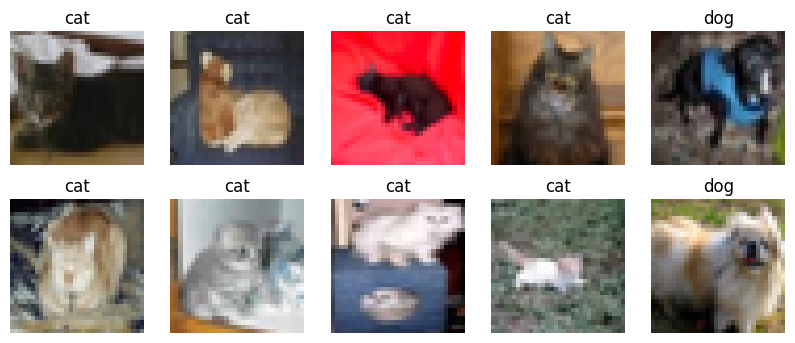

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
# =========================
# 1. CIFAR-10 데이터 로드
# =========================

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 class index
# cat: 3
# dog: 5

CAT_LABEL = 3
DOG_LABEL = 5

# =========================
# 2. Cat / Dog 데이터만 선택
# =========================

train_mask = np.where((y_train[:, 0] == CAT_LABEL) | (y_train[:, 0] == DOG_LABEL))[0]
test_mask = np.where((y_test[:, 0] == CAT_LABEL) | (y_test[:, 0] == DOG_LABEL))[0]

x_train_cd = x_train[train_mask]
y_train_cd = y_train[train_mask]

x_test_cd = x_test[test_mask]
y_test_cd = y_test[test_mask]

# =========================
# 3. 라벨 변환
# cat -> 0
# dog -> 1
# =========================

y_train_cd = np.where(y_train_cd[:, 0] == CAT_LABEL, 0, 1)
y_test_cd = np.where(y_test_cd[:, 0] == CAT_LABEL, 0, 1)

# =========================
# 4. 정규화
# =========================

x_train_cd = x_train_cd.astype("float32") / 255.0
x_test_cd = x_test_cd.astype("float32") / 255.0

print("Train data:", x_train_cd.shape)
print("Train label:", y_train_cd.shape)
print("Test data:", x_test_cd.shape)
print("Test label:", y_test_cd.shape)

# =========================
# 5. 데이터 확인
# =========================

class_names = ["cat", "dog"]

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_cd[i])
    plt.title(class_names[y_train_cd[i]])
    plt.axis("off")
plt.show()

In [15]:
# =========================
# 6. CNN 모델 구축하기
# =========================

model = tf.keras.Sequential()
model.add(layers.Input(shape=(32, 32, 3)))

model.add(layers.RandomFlip("horizontal"))
model.add(layers.RandomRotation(0.1))
model.add(layers.RandomZoom(0.1))
model.add(layers.RandomContrast(0.1))

model.add(layers.Conv2D(32,
                        (3, 3),
                        padding="same",
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4), # L2 규제 (교재 pp. 332-333)
                        ))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))


model.add(layers.Conv2D(64,
                        (3, 3),
                        padding="same",
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                        ))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(
                        128,
                        (3, 3),
                        padding="same",
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                        ))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.4))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4),
))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation="sigmoid"))

In [16]:
# =========================
# 7. 모델 컴파일
# =========================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [17]:
# =========================
# 8. Callback 설정
# =========================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

In [18]:
# =========================
# 9. 모델 학습
# =========================

history = model.fit(
    x_train_cd,
    y_train_cd,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 55s 182ms/step - accuracy: 0.5592 - loss: 0.7122 - val_accuracy: 0.5910 - val_loss: 0.6872 - learning_rate: 0.0010
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 80s 177ms/step - accuracy: 0.5944 - loss: 0.6856 - val_accuracy: 0.5980 - val_loss: 0.6763 - learning_rate: 0.0010
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 49s 174ms/step - accuracy: 0.6271 - loss: 0.6641 - val_accuracy: 0.6600 - val_loss: 0.6348 - learning_rate: 0.0010
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 50s 177ms/step - accuracy: 0.6523 - loss: 0.6455 - val_accuracy: 0.6560 - val_loss: 0.6258 - learning_rate: 0.0010
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 81s 172ms/step - accuracy: 0.6668 - loss: 0.6334 - val_accuracy: 0.6980 - val_loss: 0.6014 - learning_rate: 0.0010
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 84s 179ms/step - accuracy: 0.6769 - loss: 0.6220 - val_accuracy: 0.7020 - val_loss: 0.5902 - learning_rate: 0.0010
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - accuracy: 0.6

In [19]:
# =========================
# 10. 테스트 데이터 평가
# =========================

test_loss, test_accuracy = model.evaluate(x_test_cd, y_test_cd, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.7680 - loss: 0.5035
Test loss: 0.5034865140914917
Test accuracy: 0.7680000066757202


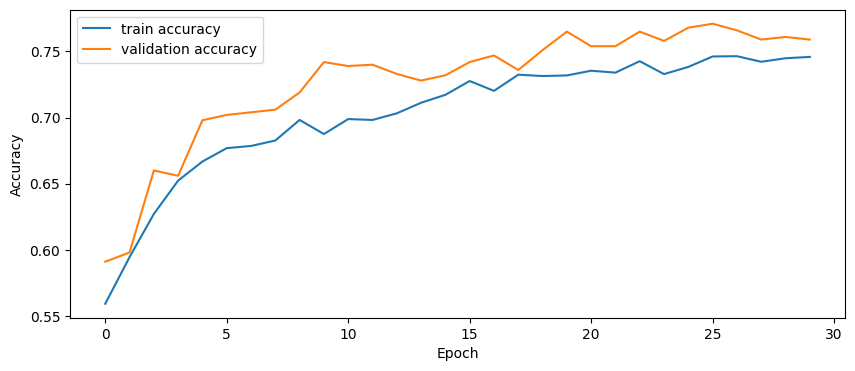

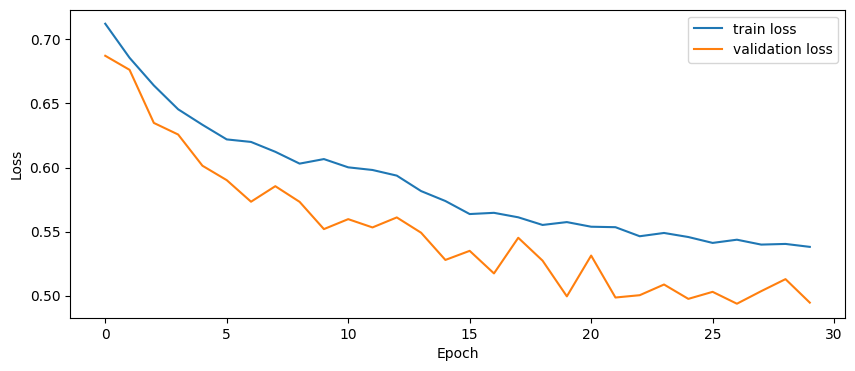

In [20]:
# =========================
# 11. 학습 과정 시각화
# =========================

plt.figure(figsize=(10, 4))

plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


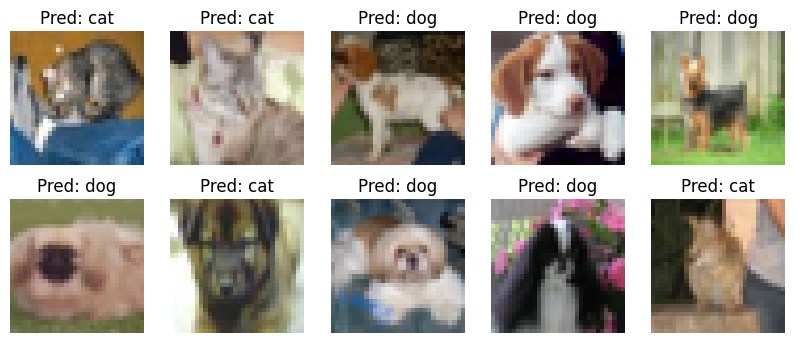

In [21]:
# =========================
# 12. 예측 결과 확인
# =========================

predictions = model.predict(x_test_cd[:10])

plt.figure(figsize=(10, 4))

for i in range(10):
    probability = predictions[i][0]
    predicted_label = 1 if probability >= 0.5 else 0

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_cd[i])
    plt.title(f"Pred: {class_names[predicted_label]}")
    plt.axis("off")

plt.show()